<a href="https://colab.research.google.com/github/chrisanuo/chrisanuo/blob/main/Split_plot_SOC_POM_MAOM_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [4]:
from google.colab import files
uploaded = files.upload()

Saving Deep Soil OC fraction_tillage data.xlsx to Deep Soil OC fraction_tillage data.xlsx


In [5]:
%%R
install.packages(c("readxl", "dplyr", "lme4", "lmerTest", "emmeans",
                   "multcomp", "multcompView", "openxlsx"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘rbibutils’, ‘zoo’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘numDeriv’, ‘estimability’, ‘mvtnorm’, ‘TH.data’, ‘sandwich’

trying URL 'https://cran.rstudio.com/src/contrib/rbibutils_2.4.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/zoo_1.8-15.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/Rdpack_2.6.6.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/minqa_1.2.8.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/nloptr_2.2.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/reformulas_0.4.4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RcppEigen_0.3.4.0.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/numDeriv_2016.8-1.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/estimability_1.5.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/mvtnorm_1.4-1.tar.gz'
trying URL 'https://c

In [6]:
%%R
library(readxl)
library(dplyr)
library(lme4)
library(lmerTest)
library(emmeans)
library(multcomp)
library(multcompView)
library(openxlsx)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: Matrix

Attaching package: ‘lmerTest’

The following object is masked from ‘package:lme4’:

    lmer

The following object is masked from ‘package:stats’:

    step

Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'
Loading required package: mvtnorm
Loading required package: survival
Loading required package: TH.data
Loading required package: MASS

Attaching package: ‘MASS’

The following object is masked from ‘package:dplyr’:

    select


Attaching package: ‘TH.data’

The following object is masked from ‘package:MASS’:

    geyser



In [7]:
%%R
file_path <- "Deep Soil OC fraction_tillage data.xlsx"

sheets <- excel_sheets(file_path)

data_all <- lapply(sheets, function(sh) {
  df <- read_excel(file_path, sheet = sh)
  df$Depth <- sh
  return(df)
}) %>%
  bind_rows()

head(data_all)

# A tibble: 6 × 20
    Rep Treatments `crop-rotation` depth  `Actual Depth` `Bulk C (g/kg)`
  <dbl> <chr>      <chr>           <chr>           <dbl>           <dbl>
1     1 No-till    B-B             0-5 cm              5            41.0
2     2 No-till    B-B             0-5 cm              5            34.1
3     3 No-till    B-B             0-5 cm              5            32.4
4     4 No-till    B-B             0-5 cm              5            35.0
5     1 No-till    C-B             0-5 cm              5            38.9
6     2 No-till    C-B             0-5 cm              5            38.6
# ℹ 14 more variables: `Bulk N (g/kg)` <dbl>, `POM-C (g/kg)` <dbl>,
#   `POM-N (g/kg)` <dbl>, `MAOM-C (g/kg)` <dbl>, `MAOM-N (g/kg)` <dbl>,
#   `Total C recovered(g/kg)` <dbl>, `Total N recovered (g/kg)` <dbl>,
#   `POM-C recovered (%)` <dbl>, `POM-N recovered (%)` <dbl>,
#   `MAOM-C recovered (%)` <dbl>, `MAOM-N recovered (%)` <dbl>,
#   `Total C (%)` <dbl>, `Total N (%)` <dbl>, Depth <chr>


In [8]:
%%R
data_all <- data_all %>%
  rename(
    Tillage = Treatments,
    Rotation = `crop-rotation`,
    BulkSOC = `Bulk C (g/kg)`,
    BulkN = `Bulk N (g/kg)`,
    POMC = `POM-C (g/kg)`,
    POMN = `POM-N (g/kg)`,
    MAOMC = `MAOM-C (g/kg)`,
    MAOMN = `MAOM-N (g/kg)`
  ) %>%
  mutate(
    Rep = as.factor(Rep),
    Depth = factor(Depth, levels = c("0-5", "5-15", "15-30", "30-50", "50-75", "75-100")),
    Tillage = recode(Tillage, "MB plow" = "Moldboard plow"),
    Tillage = factor(Tillage, levels = c("No-till", "Chisel plow", "Moldboard plow")),
    Rotation = recode(Rotation,
                      "C-C" = "Continuous corn",
                      "C-B" = "Corn-soybean",
                      "B-B" = "Continuous soybean"),
    Rotation = factor(Rotation, levels = c("Continuous corn", "Corn-soybean", "Continuous soybean"))
  )

str(data_all)

tibble [216 × 20] (S3: tbl_df/tbl/data.frame)
 $ Rep                     : Factor w/ 4 levels "1","2","3","4": 1 2 3 4 1 2 3 4 1 2 ...
 $ Tillage                 : Factor w/ 3 levels "No-till","Chisel plow",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Rotation                : Factor w/ 3 levels "Continuous corn",..: 3 3 3 3 2 2 2 2 1 1 ...
 $ depth                   : chr [1:216] "0-5 cm" "0-5 cm" "0-5 cm" "0-5 cm" ...
 $ Actual Depth            : num [1:216] 5 5 5 5 5 5 5 5 5 5 ...
 $ BulkSOC                 : num [1:216] 41 34.1 32.4 35 38.9 ...
 $ BulkN                   : num [1:216] 3.04 2.54 2.35 1.89 2.84 2.57 2.64 3.63 3.62 2.69 ...
 $ POMC                    : num [1:216] 6.38 4.1 5.83 5.12 6.22 ...
 $ POMN                    : num [1:216] 0.515 0.358 0.501 0.443 0.537 ...
 $ MAOMC                   : num [1:216] 22.8 20.6 17.5 15.1 21.4 ...
 $ MAOMN                   : num [1:216] 2.31 1.2 1.38 1.07 1.28 ...
 $ Total C recovered(g/kg) : num [1:216] 29.2 24.7 23.3 20.2 27.7 ...
 $ Total N 

In [9]:
%%R
df_depth <- data_all %>% filter(Depth == "0-5")

model <- lmer(
  BulkSOC ~ Rotation * Tillage +
    (1 | Rep) +
    (1 | Rep:Rotation),
  data = df_depth
)

anova(model)

Type III Analysis of Variance Table with Satterthwaite's method
                  Sum Sq Mean Sq NumDF DenDF  F value    Pr(>F)    
Rotation          104.10   52.05     2    24   9.5235  0.000902 ***
Tillage          2097.37 1048.68     2    24 191.8833 1.728e-15 ***
Rotation:Tillage   50.48   12.62     4    24   2.3093  0.087099 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


boundary (singular) fit: see help('isSingular')


In [10]:
%%R
emm <- emmeans(model, ~ Rotation * Tillage)

cld(
  emm,
  adjust = "none",
  Letters = letters,
  alpha = 0.05
)

 Rotation           Tillage        emmean   SE   df lower.CL upper.CL .group
 Continuous soybean Moldboard plow   21.0 1.41 15.1     18.0     24.0  a    
 Continuous corn    Moldboard plow   21.4 1.41 15.1     18.4     24.4  a    
 Corn-soybean       Moldboard plow   22.6 1.41 15.1     19.6     25.6  a    
 Continuous soybean Chisel plow      22.7 1.41 15.1     19.6     25.7  a    
 Continuous corn    Chisel plow      26.3 1.41 15.1     23.3     29.3   b   
 Corn-soybean       Chisel plow      27.3 1.41 15.1     24.3     30.3   b   
 Continuous soybean No-till          35.6 1.41 15.1     32.6     38.7    c  
 Corn-soybean       No-till          39.8 1.41 15.1     36.8     42.8     d 
 Continuous corn    No-till          42.7 1.41 15.1     39.7     45.7     d 

Degrees-of-freedom method: satterthwaite 
Confidence level used: 0.95 
significance level used: alpha = 0.05 
NOTE: If two or more means share the same grouping symbol,
      then we cannot show them to be different.
      But we

Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed


In [11]:
%%R
variables <- c("BulkSOC", "BulkN", "POMC", "POMN", "MAOMC", "MAOMN")
depths <- levels(data_all$Depth)

anova_results <- list()
lsd_results <- list()

for (var in variables) {
  for (dep in depths) {

    df_depth <- data_all %>% filter(Depth == dep)

    formula_text <- paste0(
      var, " ~ Rotation * Tillage + (1 | Rep) + (1 | Rep:Rotation)"
    )

    model <- lmer(as.formula(formula_text), data = df_depth)

    anova_tbl <- as.data.frame(anova(model))
    anova_tbl$Effect <- rownames(anova_tbl)
    anova_tbl$Variable <- var
    anova_tbl$Depth <- dep

    anova_results[[paste(var, dep, sep = "_")]] <- anova_tbl

    emm <- emmeans(model, ~ Rotation * Tillage)

    lsd_tbl <- cld(
      emm,
      adjust = "none",
      Letters = letters,
      alpha = 0.05
    ) %>%
      as.data.frame()

    lsd_tbl$Variable <- var
    lsd_tbl$Depth <- dep

    lsd_results[[paste(var, dep, sep = "_")]] <- lsd_tbl
  }
}

anova_final <- bind_rows(anova_results)
lsd_final <- bind_rows(lsd_results)

head(anova_final)
head(lsd_final)

 Rotation           Tillage         emmean      SE    df lower.CL upper.CL
 Continuous soybean Moldboard plow 20.9625 1.41212 15.06 17.95367 23.97133
 Continuous corn    Moldboard plow 21.4125 1.41212 15.06 18.40367 24.42133
 Corn-soybean       Moldboard plow 22.5825 1.41212 15.06 19.57367 25.59133
 Continuous soybean Chisel plow    22.6550 1.41212 15.06 19.64617 25.66383
 Continuous corn    Chisel plow    26.3175 1.41212 15.06 23.30867 29.32633
 Corn-soybean       Chisel plow    27.2800 1.41212 15.06 24.27117 30.28883
 .group Variable Depth
  a     BulkSOC  0-5  
  a     BulkSOC  0-5  
  a     BulkSOC  0-5  
  a     BulkSOC  0-5  
   b    BulkSOC  0-5  
   b    BulkSOC  0-5  

Degrees-of-freedom method: satterthwaite 
Confidence level used: 0.95 
significance level used: alpha = 0.05 
NOTE: If two or more means share the same grouping symbol,
      then we cannot show them to be different.
      But we also did not show them to be the same. 


boundary (singular) fit: see help('isSingular')
Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed
Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed
boundary (singular) fit: see help('isSingular')
Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed
boundary (singular) fit: see help('isSingular')
Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed
boundary (singular) fit: see help('isSingular')
Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed
boundary (singular) fit: see help('isSingular')
Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed
Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed
boundary (singular) fit: see help('isSingular')
Cannot use mode = "kenward-roger" because *pbkrtest* package is not installed
boundary (singular) fit: see help('isSingular')
Cannot use mode = "kenward-roger" becaus

In [12]:
%%R
write.xlsx(
  list(
    ANOVA = anova_final,
    Fisher_LSD = lsd_final
  ),
  file = "split_plot_ANOVA_Fisher_LSD_results.xlsx"
)

In [13]:
from google.colab import files
files.download("split_plot_ANOVA_Fisher_LSD_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
%%R
install.packages(c("ggplot2", "patchwork"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/patchwork_1.3.2.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpGC1kPJ/downloaded_packages’


In [15]:
%%R
library(ggplot2)
library(patchwork)

Need help getting started? Try the R Graphics Cookbook:
https://r-graphics.org

Attaching package: ‘patchwork’

The following object is masked from ‘package:MASS’:

    area



In [26]:
%%R
plot_stack <- function(data, var1, var2, xlab1, xlab2, file_name, show_legend = TRUE) {

  data_long <- data %>%
    dplyr::select(Depth, Rep, Tillage, Rotation, all_of(var1), all_of(var2)) %>%
    rename(
      Top = all_of(var1),
      Bottom = all_of(var2)
    ) %>%
    tidyr::pivot_longer(
      cols = c(Top, Bottom),
      names_to = "Variable",
      values_to = "Value"
    ) %>%
    mutate(
      Variable = recode(Variable,
                        "Top" = xlab1,
                        "Bottom" = xlab2),
      Variable = factor(Variable, levels = c(xlab1, xlab2))
    )

  p <- ggplot(data_long, aes(x = Value, y = Depth, fill = Rotation)) +
    geom_boxplot(
      position = position_dodge(width = 0.75),
      width = 0.55,
      outlier.size = 1.5,
      linewidth = 0.45
    ) +
    facet_grid(Variable ~ Tillage, scales = "free_x") +
    scale_fill_manual(values = c(
      "Continuous corn" = "#0072B2",
      "Corn-soybean" = "#E69F00",
      "Continuous soybean" = "#CC79A7"
    )) +
    scale_y_discrete(limits = rev(levels(data$Depth))) +
    theme_classic(base_size = 13) +
    theme(
      strip.text = element_text(face = "bold", size = 13),
      axis.title.y = element_text(face = "bold"),
      axis.title.x = element_text(face = "bold"),
      axis.text = element_text(color = "black"),
      legend.position = ifelse(show_legend, "bottom", "none"),
      legend.title = element_text(face = "bold"),
      panel.border = element_rect(color = "black", fill = NA, linewidth = 0.7),
      strip.background = element_blank()
    ) +
    labs(
      x = NULL,
      y = "Soil depth (cm)",
      fill = "Crop rotation"
    )

  ggsave(file_name, p, width = 12, height = 8, dpi = 600)
  return(p)
}

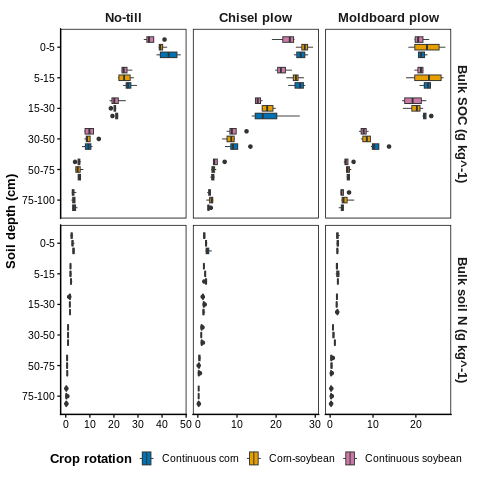

In [27]:
%%R
bulk_fig <- plot_stack(
  data_all,
  var1 = "BulkSOC",
  var2 = "BulkN",
  xlab1 = "Bulk SOC (g kg^-1)",
  xlab2 = "Bulk soil N (g kg^-1)",
  file_name = "Bulk_SOC_N_figure.png",
  show_legend = TRUE
)

bulk_fig

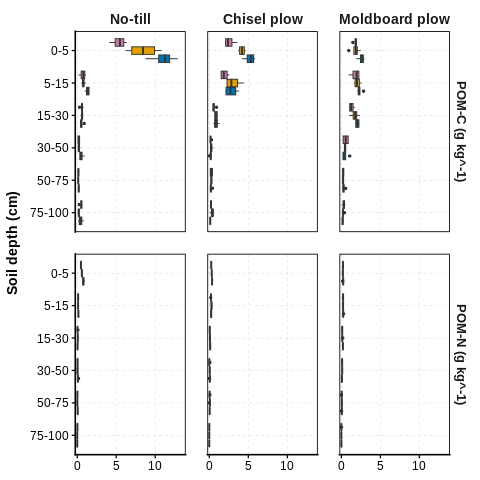

In [39]:
%%R
pom_fig <- plot_stack_publication(
  data_all,
  var1 = "POMC",
  var2 = "POMN",
  xlab1 = "POM-C (g kg^-1)",
  xlab2 = "POM-N (g kg^-1)",
  file_name = "POM_C_N_publication.png",
  show_legend = FALSE
)

pom_fig

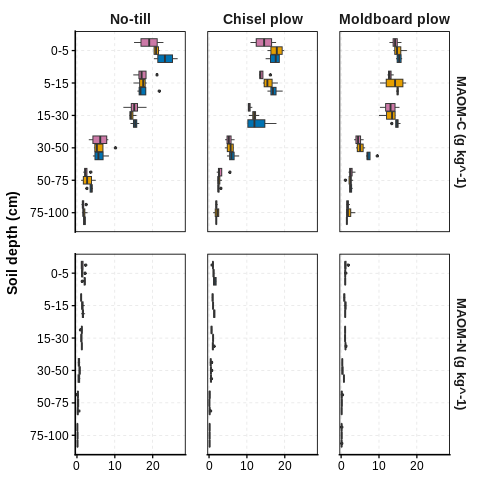

In [43]:
%%R
maom_fig <- plot_stack_publication(
  data_all,
  var1 = "MAOMC",
  var2 = "MAOMN",
  xlab1 = "MAOM-C (g kg^-1)",
  xlab2 = "MAOM-N (g kg^-1)",
  file_name = "MAOM_C_N_publication.png",
  show_legend = FALSE
)

maom_fig

In [42]:
%%R
library(ggplot2)
library(dplyr)
library(tidyr)

plot_stack_publication <- function(data, var1, var2, xlab1, xlab2, file_name, show_legend = TRUE) {

  data_long <- data %>%
    dplyr::select(Depth, Rep, Tillage, Rotation, all_of(var1), all_of(var2)) %>%
    rename(
      Top = all_of(var1),
      Bottom = all_of(var2)
    ) %>%
    pivot_longer(
      cols = c(Top, Bottom),
      names_to = "Variable",
      values_to = "Value"
    ) %>%
    mutate(
      Variable = recode(Variable, "Top" = xlab1, "Bottom" = xlab2),
      Variable = factor(Variable, levels = c(xlab1, xlab2)),
      Depth = factor(Depth, levels = c("75-100", "50-75", "30-50", "15-30", "5-15", "0-5"))
    )

  p <- ggplot(data_long, aes(x = Value, y = Depth, fill = Rotation)) +
    geom_boxplot(
      position = position_dodge(width = 0.75),
      width = 0.7, # Increased boxplot width
      outlier.size = 1.2,
      outlier.stroke = 0.3,
      linewidth = 0.45
    ) +
    facet_grid(
      Variable ~ Tillage,
      scales = "fixed"
    ) +
    scale_fill_manual(values = c(
      "Continuous corn" = "#0072B2",
      "Corn-soybean" = "#E69F00",
      "Continuous soybean" = "#CC79A7"
    )) +
    scale_x_continuous(expand = expansion(mult = c(0.02, 0.08))) +
    theme_classic(base_size = 14) +
    theme(
      text = element_text(family = "sans", color = "black"),
      strip.text.x = element_text(face = "bold", size = 14),
      strip.text.y = element_text(face = "bold", size = 13),
      strip.background = element_blank(),
      axis.text = element_text(color = "black", size = 12),
      axis.title.y = element_text(face = "bold", size = 14, margin = margin(r = 10)),
      axis.title.x = element_blank(),
      axis.line = element_line(color = "black", linewidth = 0.7),
      axis.ticks = element_line(color = "black", linewidth = 0.6),
      panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8),
      panel.grid.major = element_line(color = "grey85", linewidth = 0.25, linetype = "dashed"),
      panel.grid.minor = element_blank(),
      legend.position = ifelse(show_legend, "bottom", "none"),
      legend.title = element_text(face = "bold", size = 12),
      legend.text = element_text(size = 11),
      legend.key.width = unit(1.4, "cm"),
      panel.spacing = unit(1.5, "lines") # Increased panel spacing
    ) +
    labs(
      x = NULL,
      y = "Soil depth (cm)",
      fill = "Crop rotation"
    )

  ggsave(file_name, p, width = 13.5, height = 8.5, dpi = 600, bg = "white")
  ggsave(gsub(".png", ".pdf", file_name), p, width = 13.5, height = 8.5, dpi = 600, bg = "white")

  return(p)
}

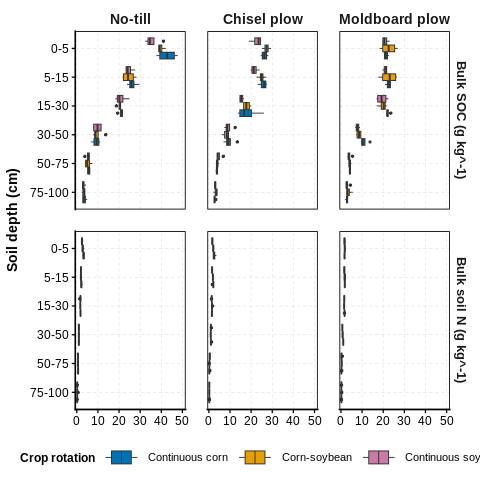

In [44]:
%%R
bulk_fig <- plot_stack_publication(
  data_all,
  var1 = "BulkSOC",
  var2 = "BulkN",
  xlab1 = "Bulk SOC (g kg^-1)",
  xlab2 = "Bulk soil N (g kg^-1)",
  file_name = "Bulk_SOC_N_publication.png",
  show_legend = TRUE
)

bulk_fig

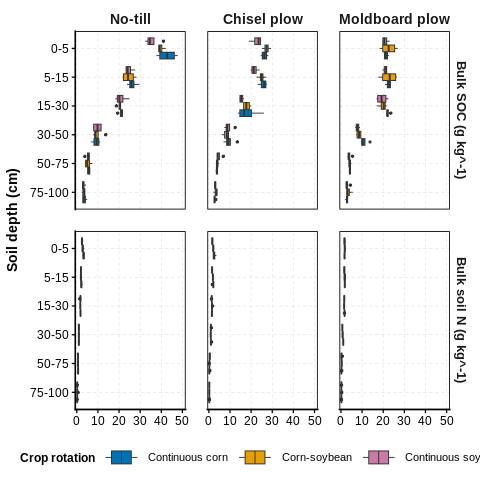

In [45]:
%%R
bulk_fig <- plot_stack_publication(
  data_all,
  var1 = "BulkSOC",
  var2 = "BulkN",
  xlab1 = "Bulk SOC (g kg^-1)",
  xlab2 = "Bulk soil N (g kg^-1)",
  file_name = "Bulk_SOC_N_publication.png",
  show_legend = TRUE
)

bulk_fig

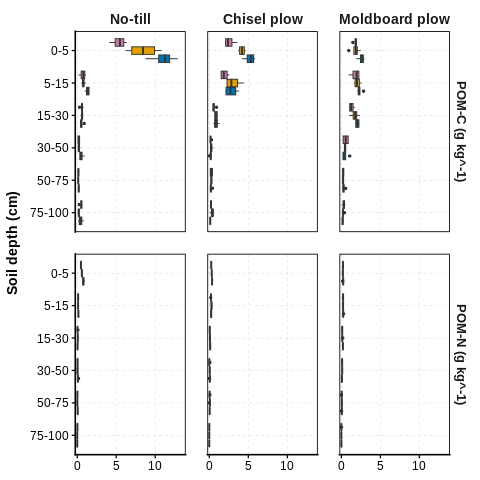

In [47]:
%%R
pom_fig <- plot_stack_publication(
  data_all,
  var1 = "POMC",
  var2 = "POMN",
  xlab1 = "POM-C (g kg^-1)",
  xlab2 = "POM-N (g kg^-1)",
  file_name = "POM_C_N_publication.png",
  show_legend = FALSE
)

pom_fig

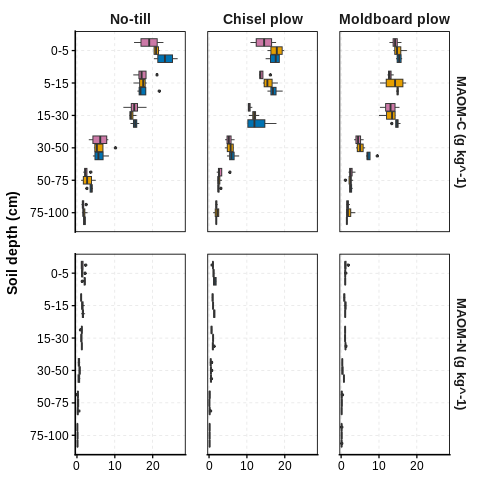

In [48]:
%%R
maom_fig <- plot_stack_publication(
  data_all,
  var1 = "MAOMC",
  var2 = "MAOMN",
  xlab1 = "MAOM-C (g kg^-1)",
  xlab2 = "MAOM-N (g kg^-1)",
  file_name = "MAOM_C_N_publication.png",
  show_legend = FALSE
)

maom_fig

In [62]:
%%R
library(ggplot2)
library(dplyr)
library(patchwork)

plot_one_variable <- function(data, var, xlab, show_titles = TRUE, show_legend = FALSE) {

  ggplot(data, aes(x = .data[[var]], y = Depth, fill = Rotation)) +
    geom_boxplot(
      position = position_dodge(width = 0.8),
      width = 0.7, # Increased boxplot width
      linewidth = 0.6,
      outlier.size = 1.6,
      outlier.stroke = 0.4
    ) +
    facet_wrap(~ Tillage, nrow = 1, scales = "fixed") +
    scale_fill_manual(values = c(
      "Continuous corn" = "#0072B2",
      "Corn-soybean" = "#E69F00",
      "Continuous soybean" = "#CC79A7"
    )) +
    scale_y_discrete(limits = rev(c("0-5", "5-15", "15-30", "30-50", "50-75", "75-100"))) +
    scale_x_continuous(expand = expansion(mult = c(0.02, 0.10))) +
    labs(x = xlab, y = "Soil depth (cm)", fill = "Crop rotation") +
    theme_classic(base_size = 14) +
    theme(
      strip.text = if (show_titles) element_text(face = "bold", size = 14) else element_blank(),
      strip.background = element_blank(),
      axis.title.x = element_text(face = "bold", size = 14, margin = margin(t = 12)),
      axis.title.y = element_text(face = "bold", size = 14, margin = margin(r = 10)),
      axis.text = element_text(color = "black", size = 12),
      axis.line = element_line(color = "black", linewidth = 0.8),
      axis.ticks = element_line(color = "black", linewidth = 0.7),
      panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8),
      panel.grid.major = element_line(color = "grey85", linewidth = 0.3, linetype = "dashed"),
      panel.grid.minor = element_blank(),
      panel.spacing = unit(1.5, "lines"), # Increased panel spacing
      legend.position = ifelse(show_legend, "bottom", "none"),
      legend.title = element_text(face = "bold"),
      legend.text = element_text(size = 11)
    )
}

In [75]:
%%R
bulk_soc <- plot_one_variable(data_all, "BulkSOC", "Bulk SOC (g kg^-1)", show_titles = TRUE, show_legend = TRUE) +
  scale_x_continuous(limits = c(0, 50), expand = expansion(mult = c(0.02, 0.08))) +
  theme(
    legend.position = c(0.15, 0.25), # Adjusting position to be more central under 'No-till'
    legend.justification = c(0, 0) # Anchor bottom-left of the legend at the specified position
  )
bulk_n   <- plot_one_variable(data_all, "BulkN", "Bulk soil N (g kg^-1)", show_titles = FALSE, show_legend = FALSE) +
  scale_x_continuous(limits = c(0, 50), expand = expansion(mult = c(0.02, 0.08)))

bulk_fig <- bulk_soc / bulk_n + plot_layout(heights = c(1, 1))

ggsave("Bulk_SOC_N_publication_ready.png", bulk_fig, width = 14, height = 9.5, dpi = 600, bg = "white")
ggsave("Bulk_SOC_N_publication_ready.pdf", bulk_fig, width = 14, height = 9.5, dpi = 600, bg = "white")

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


In [68]:
%%R
pom_c <- plot_one_variable(data_all, "POMC", "POM-C (g kg^-1)", show_titles = TRUE, show_legend = FALSE)
pom_n <- plot_one_variable(data_all, "POMN", "POM-N (g kg^-1)", show_titles = FALSE, show_legend = FALSE)

pom_fig <- pom_c / pom_n + plot_layout(heights = c(1, 1))

ggsave("POM_C_N_publication_ready.png", pom_fig, width = 14, height = 9.5, dpi = 600, bg = "white")
ggsave("POM_C_N_publication_ready.pdf", pom_fig, width = 14, height = 9.5, dpi = 600, bg = "white")

In [69]:
%%R
maom_c <- plot_one_variable(data_all, "MAOMC", "MAOM-C (g kg^-1)", show_titles = TRUE, show_legend = FALSE)
maom_n <- plot_one_variable(data_all, "MAOMN", "MAOM-N (g kg^-1)", show_titles = FALSE, show_legend = FALSE)

maom_fig <- maom_c / maom_n + plot_layout(heights = c(1, 1))

ggsave("MAOM_C_N_publication_ready.png", maom_fig, width = 14, height = 9.5, dpi = 600, bg = "white")
ggsave("MAOM_C_N_publication_ready.pdf", maom_fig, width = 14, height = 9.5, dpi = 600, bg = "white")

In [63]:
%%R
ggsave(
  "Bulk_SOC_N_publication_ready.png",
  bulk_fig,
  width = 14,
  height = 9.5,
  dpi = 600,
  bg = "white"
)

ggsave(
  "Bulk_SOC_N_publication_ready.pdf",
  bulk_fig,
  width = 14,
  height = 9.5,
  bg = "white"
)

In [64]:
%%R
ggsave(
  "POM_C_N_publication_ready.png",
  pom_fig,
  width = 14,
  height = 9.5,
  dpi = 600,
  bg = "white"
)

ggsave(
  "POM_C_N_publication_ready.pdf",
  pom_fig,
  width = 14,
  height = 9.5,
  bg = "white"
)

In [65]:
%%R
ggsave(
  "MAOM_C_N_publication_ready.png",
  maom_fig,
  width = 14,
  height = 9.5,
  dpi = 600,
  bg = "white"
)

ggsave(
  "MAOM_C_N_publication_ready.pdf",
  maom_fig,
  width = 14,
  height = 9.5,
  bg = "white"
)

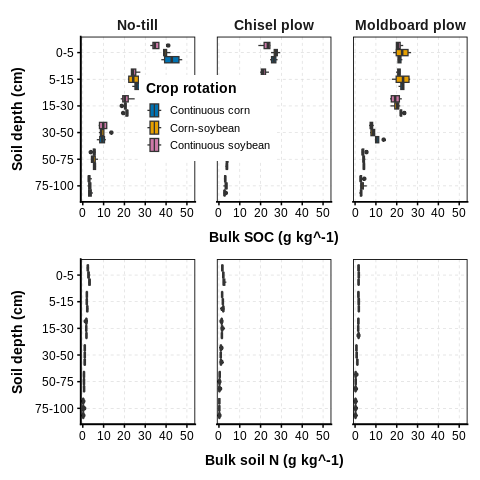

In [76]:
%%R
bulk_fig

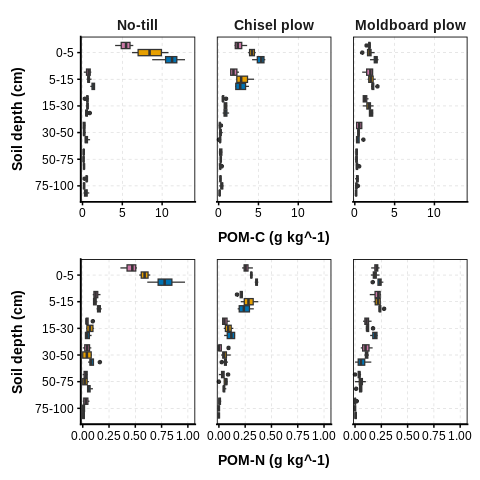

In [77]:
%%R
pom_fig

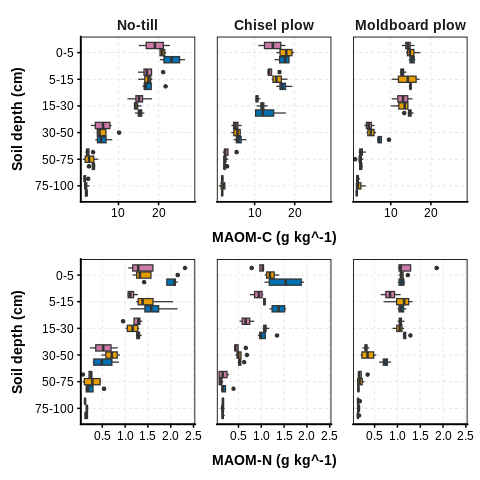

In [78]:
%%R
maom_fig

In [79]:
%%R
install.packages(c("ggplot2", "dplyr", "tidyr", "patchwork", "showtext"))

library(ggplot2)
library(dplyr)
library(tidyr)
library(patchwork)
library(showtext)

showtext_auto()

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘sysfonts’, ‘showtextdb’

trying URL 'https://cran.rstudio.com/src/contrib/sysfonts_0.8.9.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/showtextdb_3.0.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/ggplot2_4.0.3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/dplyr_1.2.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/tidyr_1.3.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/patchwork_1.3.2.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/showtext_0.9-8.tar.gz'

The downloaded source packages are in
	‘/tmp/RtmpGC1kPJ/downloaded_packages’
Loading required package: sysfonts
Loading required package: showtextdb


In [82]:
%%R
plot_one_variable <- function(data, var, xlab, show_titles = TRUE, show_legend = FALSE) {

  data <- data %>%
    mutate(
      Depth = factor(Depth, levels = c("75-100", "50-75", "30-50", "15-30", "5-15", "0-5")),
      Tillage = factor(Tillage, levels = c("No-till", "Chisel plow", "Moldboard plow")),
      Rotation = factor(Rotation, levels = c("Continuous corn", "Corn-soybean", "Continuous soybean"))
    )

  ggplot(data, aes(x = .data[[var]], y = Depth, fill = Rotation)) +
    geom_boxplot(
      position = position_dodge2(width = 0.82, preserve = "single"),
      width = 0.58,
      linewidth = 0.55,
      outlier.size = 1.4,
      outlier.stroke = 0.35,
      color = "black"
    ) +
    facet_wrap(~ Tillage, nrow = 1, scales = "fixed") +
    scale_fill_manual(values = c(
      "Continuous corn" = "#0072B2",
      "Corn-soybean" = "#E69F00",
      "Continuous soybean" = "#CC79A7"
    )) +
    scale_x_continuous(expand = expansion(mult = c(0.02, 0.10))) +
    labs(x = xlab, y = "Soil depth (cm)", fill = "Crop rotation") +
    theme_classic(base_size = 14) +
    theme(
      strip.text = if (show_titles) element_text(face = "bold", size = 15) else element_blank(),
      strip.background = element_blank(),

      axis.title.x = element_text(face = "bold", size = 14, margin = margin(t = 14)),
      axis.title.y = element_text(face = "bold", size = 14, margin = margin(r = 12)),
      axis.text = element_text(color = "black", size = 12),
      axis.line = element_line(color = "black", linewidth = 0.8),
      axis.ticks = element_line(color = "black", linewidth = 0.7),

      panel.border = element_rect(color = "black", fill = NA, linewidth = 0.85),
      panel.grid.major = element_line(color = "grey86", linewidth = 0.28, linetype = "dashed"),
      panel.grid.minor = element_blank(),
      panel.spacing = unit(0.65, "lines"),

      legend.position = ifelse(show_legend, "bottom", "none"),
      legend.title = element_text(face = "bold", size = 12),
      legend.text = element_text(size = 11),
      legend.key.width = unit(1.4, "cm"),
      plot.margin = margin(8, 8, 8, 8)
    )
}

In [83]:
%%R
bulk_soc <- plot_one_variable(data_all, "BulkSOC", "Bulk SOC (g kg^-1)", show_titles = TRUE, show_legend = TRUE)
bulk_n   <- plot_one_variable(data_all, "BulkN", "Bulk soil N (g kg^-1)", show_titles = FALSE, show_legend = FALSE)

bulk_fig <- bulk_soc / bulk_n + plot_layout(heights = c(1, 1))

pom_c <- plot_one_variable(data_all, "POMC", "POM-C (g kg^-1)", show_titles = TRUE, show_legend = FALSE)
pom_n <- plot_one_variable(data_all, "POMN", "POM-N (g kg^-1)", show_titles = FALSE, show_legend = FALSE)

pom_fig <- pom_c / pom_n + plot_layout(heights = c(1, 1))

maom_c <- plot_one_variable(data_all, "MAOMC", "MAOM-C (g kg^-1)", show_titles = TRUE, show_legend = FALSE)
maom_n <- plot_one_variable(data_all, "MAOMN", "MAOM-N (g kg^-1)", show_titles = FALSE, show_legend = FALSE)

maom_fig <- maom_c / maom_n + plot_layout(heights = c(1, 1))

In [84]:
%%R
ggsave("Bulk_SOC_N_publication_ready.png", bulk_fig, width = 14.5, height = 10, dpi = 600, bg = "white")
ggsave("Bulk_SOC_N_publication_ready.pdf", bulk_fig, width = 14.5, height = 10, bg = "white")

ggsave("POM_C_N_publication_ready.png", pom_fig, width = 14.5, height = 10, dpi = 600, bg = "white")
ggsave("POM_C_N_publication_ready.pdf", pom_fig, width = 14.5, height = 10, bg = "white")

ggsave("MAOM_C_N_publication_ready.png", maom_fig, width = 14.5, height = 10, dpi = 600, bg = "white")
ggsave("MAOM_C_N_publication_ready.pdf", maom_fig, width = 14.5, height = 10, bg = "white")

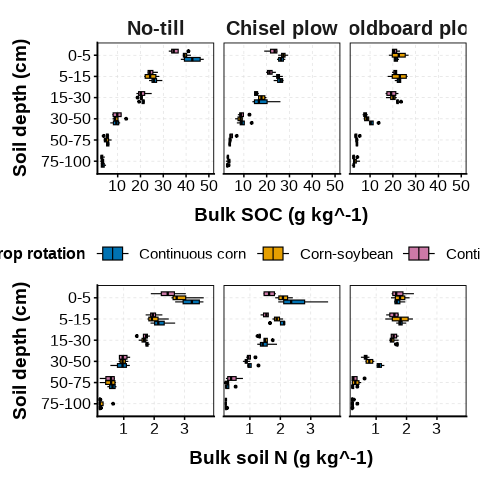

In [85]:
%%R
bulk_fig